# Neural tissue segmentation with simulated training data

Training a network to segment neural tissue normally requires many manually annotated images, which are expensive to produce. Instead, we simulate images that resemble the experimental images together with their perfect segmentation masks, train a U-Net on them, and evaluate on real data.

## 1. Load the experimental data

The dataset consists of 20 serial-section Transmission Electron Microscopy (ssTEM) images (1024 × 1024 pixels) of the ventral nerve cord of *Drosophila melanogaster*, the fruit fly, together with ground-truth segmentations. The dataset provides labels for two structures: the neuronal intracellular regions and the mitochondria. As a simplification, we treat everything else as a third class, and since these regions are dominated by the cell membranes, we will refer to the three channels as membrane, intracellular, and mitochondria.

We start by importing the libraries, downloading the dataset, and building a DeepTrack pipeline that loads each experimental image with its segmentation mask.

In [ ]:
import os

import cv2
import numpy as np
import pandas as pd
import scipy.ndimage as ndi
from scipy.spatial import Voronoi

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

import torch
from torch.utils.data import Dataset
import lightning.pytorch.callbacks as callbacks
from lightning.pytorch.callbacks import EarlyStopping
from lightning.pytorch.loggers import CSVLogger
from torchmetrics.classification import MulticlassJaccardIndex

import deeplay as dl
import deeptrack as dt

from lightning.pytorch import seed_everything
seed_everything(78, workers=True);

Seed set to 78


In [2]:
dataset_dir = "tissue_images_dataset"
# Download the dataset if it is not already present.
if not os.path.exists(dataset_dir):
    os.system("git clone https://github.com/DeepTrackAI/tissue_images_dataset")

raw_path = os.path.join(dataset_dir, "stack1", "raw")
seg_path = os.path.join(dataset_dir, "stack1", "labels")

# Pair each raw image with its segmentation label.
raw_paths = dt.sources.ImageFolder(root=raw_path)
seg_paths = dt.sources.ImageFolder(root=seg_path)
path = dt.sources.Source(raw=raw_paths, label=seg_paths)

# Augment the dataset with the four up/down + left/right flip combinations.
srcs = path.product(flip_ud=[True, False], flip_lr=[True, False])
sources = dt.sources.Join(srcs)

print(f"Raw images: {len(raw_paths)}")
print(f"Segmentation labels: {len(seg_paths)}")

Raw images: 20
Segmentation labels: 20


### 1.1 Build the pipeline for the experimental images

We build a DeepTrack pipeline that loads each experimental image and its segmentation mask, keeps only the labels for the neuronal intracellular regions and mitochondria, and applies the random up/down and left/right flips for data augmentation.

In [3]:
def select_labels(class_labels):
    """Keep only the given label values and one-hot encode them."""

    def inner(segmentation):
        seg = segmentation.squeeze()
        remapped = np.select(
            [seg == c for c in class_labels],
            np.arange(len(class_labels)) + 1,
            default=0,
        ).astype(np.uint8)
        return np.eye(len(class_labels) + 1)[remapped]

    return inner

In [4]:
# Load and normalize the experimental image to the range [0, 1].
im_pip_exp = dt.LoadImage(sources.raw.path) >> dt.NormalizeMinMax()

# Load the mask and one-hot encode the selected label values.
seg_pip_exp = dt.LoadImage(sources.label.path) >> dt.Lambda(
    select_labels, class_labels=[255, 191]
)

# Combine image and mask, apply matching flips, move the channel axis
# to the front, and convert to a PyTorch tensor.
pip_exp = (
    (im_pip_exp & seg_pip_exp)
    >> dt.FlipLR(sources.flip_lr)
    >> dt.FlipUD(sources.flip_ud)
    >> dt.MoveAxis(2, 0)
    >> dt.pytorch.ToTensor(dtype=torch.float)
)

In [5]:
exp_dataset = dt.pytorch.Dataset(pip_exp, srcs)

### 1.2 Visualize an experimental sample

Let's look at one sample from the dataset: the experimental image next to its three ground-truth channels (membrane, intracellular regions, and mitochondria).

In [6]:
channel_colors = [
    (0 / 255, 88 / 255, 160 / 255),     # membrane      - blue
    (81 / 255, 164 / 255, 81 / 255),    # intracellular - green
    (241 / 255, 154 / 255, 71 / 255),   # mitochondria  - orange
]

# Colormap for the argmax plots: the intracellular (background) class is shown
# white so the membrane and mitochondria stand out.
seg_cmap = ListedColormap([channel_colors[0], (1, 1, 1), channel_colors[2]])


def plot_channels(image, masks, image_title="Image", figsize=(12, 4)):
    """Show an image next to its per-class ground-truth channels."""
    fig, axs = plt.subplots(1, 4, figsize=figsize)

    axs[0].imshow(image.permute(1, 2, 0), cmap="gray")
    axs[0].set_title(image_title, fontsize=16)
    axs[0].set_axis_off()

    for i in range(masks.shape[0]):
        color_mask = torch.ones(3, *masks.shape[1:])  # white background
        for c in range(3):
            color_mask[c][masks[i] > 0.5] = channel_colors[i][c]
        axs[i + 1].imshow(color_mask.permute(1, 2, 0))
        axs[i + 1].set_title(f"Ground Truth Ch. {i}", fontsize=16)
        axs[i + 1].set_axis_off()

    plt.tight_layout()
    plt.show();

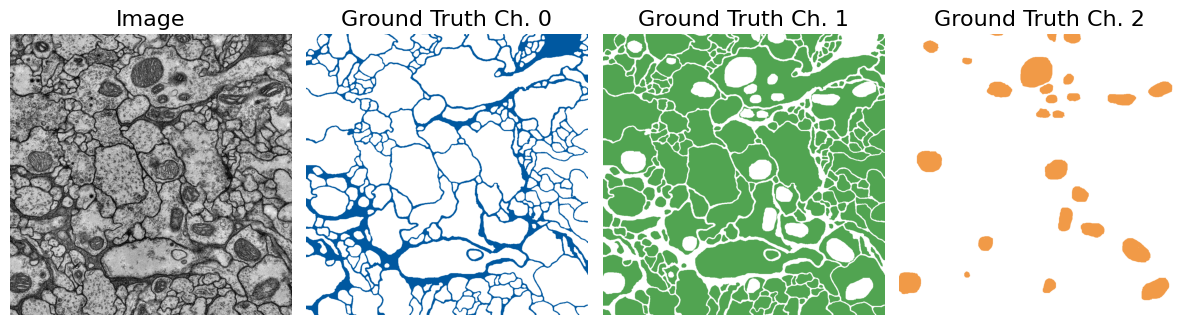

In [7]:
image, segmentation = exp_dataset[0]
plot_channels(image, segmentation)

To reduce simulation and training time, we will work with 512 × 512 images instead of the full 1024 × 1024 experimental images. Below we crop an experimental sample to that size to preview how it looks.

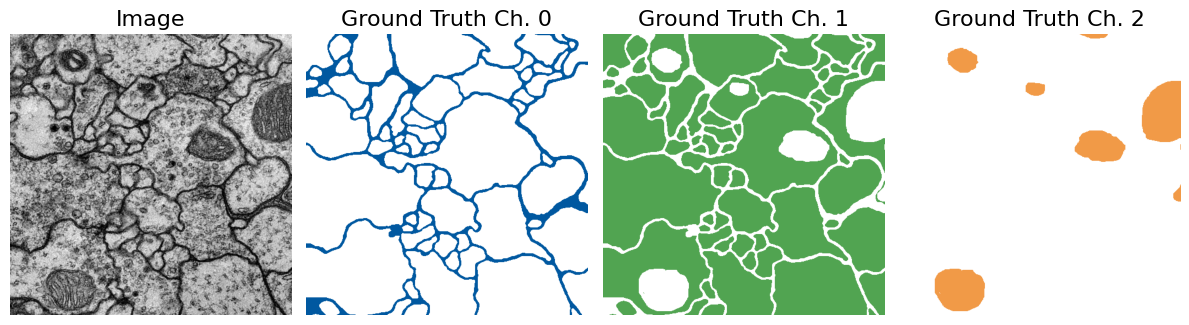

In [8]:
image, segmentation = exp_dataset[0]

size = image.shape[1] // 2
exp_image_crop = image[:, :size, :size]
segmentation_exp_crop = segmentation[:, :size, :size]

plot_channels(exp_image_crop, segmentation_exp_crop)

## 2. Simulate the data

We build each simulated image structure-by-structure, starting with membranes, then adding mitochondria, background noise, and a microscope optics model, before combining everything.

### 2.1 Membrane

We start the membrane from a Voronoi diagram. First we sample seed points: some are grouped in clusters, which gives small Voronoi cells resembling the tightly packed regions in the experimental images, and some are spread randomly across the image. A Voronoi diagram is then built from these points, and its edges form the starting shape of the membrane.

We also use the Voronoi cells in two further ways. Some of the smaller cells are filled in, to mimic the wider membrane sections seen in the experimental images. And the centers of the larger cells are saved as candidate sites for placing mitochondria later, which helps keep the mitochondria away from the membranes.

In [9]:
class Membrane(dt.Feature):
    """Generate a Voronoi-based membrane network.

    Seed points (partly clustered, partly random) define a Voronoi diagram
    whose edges become the membranes. Some small cells are filled in to mimic
    thick membrane sections, and the centers of the largest cells are stored
    in `mitochondria_sites` as candidate locations for mitochondria.
    """

    def __init__(
        self,
        image_size,
        num_points=40,
        num_clusters=4,
        num_random_points=15,
        thickness=4,
        fill_probability=0.05,
        num_mitochondria_sites=10,
        mitochondria_sites=None,
        mitochondria_size=None,
        **kwargs
    ):
        super().__init__(
            image_size=image_size,
            num_points=num_points,
            num_clusters=num_clusters,
            num_random_points=num_random_points,
            thickness=thickness,
            num_mitochondria_sites=num_mitochondria_sites,
            mitochondria_sites=mitochondria_sites,
            mitochondria_size=mitochondria_size,
            **kwargs,
        )

        self.fill_probability = fill_probability

    def generate_clustered_points(
        self, image_size, num_clusters, num_points, num_random_points
    ):
        """Sample seed points: some grouped into clusters, plus some spread
        uniformly (slightly beyond the image borders)."""

        # create cluster locations and standard deviations
        cluster_centers = np.random.uniform(
            -0.075 * image_size, 1.075 * image_size, size=(num_clusters, 2)
        )
        cluster_stds = np.random.uniform(
            0.05 * image_size, 0.1 * image_size, size=(num_clusters, 2)
        )

        # randomly put points into clusters
        cluster_ids = np.random.choice(num_clusters, size=num_points)

        # these points get positions from the distribution they belong to
        clustered_points = np.random.normal(
            loc=cluster_centers[cluster_ids], scale=cluster_stds[cluster_ids]
        )

        # add random points
        if num_random_points > 0:
            random_points = np.random.uniform(
                -0.3 * image_size,
                1.3 * image_size,
                size=(num_random_points, 2),
            )
            points = np.vstack([clustered_points, random_points])

        else:
            points = clustered_points

        return points

    def draw_line(self, start, end, mask, thickness):
        """Draw a single membrane segment onto the mask."""
        cv2.polylines(
            mask,
            [np.array([start, end], dtype=np.int32)],
            isClosed=False,
            color=1,
            thickness=thickness,
        )

    def draw_edges(self, vor, mask, thickness):
        """Draw all finite Voronoi ridges as membrane segments."""
        for ridge in vor.ridge_vertices:
            if -1 not in ridge:
                start = vor.vertices[ridge[0]]
                end = vor.vertices[ridge[1]]
                self.draw_line(start, end, mask, thickness)

    def fill_cells_and_collect_sites(self, vor, mask, image_size):
        """Fill some small cells and return candidate mitochondria sites
        (the cell centers that lie inside the image and outside filled areas).
        """
        areas = []
        centroids = []

        for region_idx in vor.point_region:
            region = vor.regions[region_idx]
            if not -1 in region and len(region) > 0:
                polygon = np.array(
                    [vor.vertices[i] for i in region], dtype=np.int32
                )

                # Fill small cells more often than large ones.
                area = cv2.contourArea(polygon)
                relative_area = area / (image_size * image_size)
                size_factor = np.exp(-relative_area * 40)
                p = self.fill_probability * size_factor
                if np.random.rand() < p:
                    cv2.fillPoly(mask, [polygon], 1)

                # Store the cell center as a mitochondria site, but only if it
                # lies inside the image and is not in a filled area.
                M = cv2.moments(polygon)
                if M["m00"] != 0:
                    cx = int(M["m10"] / M["m00"])
                    cy = int(M["m01"] / M["m00"])
                    centroid = (cy, cx)

                    if (
                        (cx > 0)
                        & (cx < image_size)
                        & (cy > 0)
                        & (cy < image_size)
                    ):
                        if mask[cy, cx] == 0:
                            areas.append(area)
                            centroids.append(centroid)

        return areas, centroids

    def get(
        self,
        image,
        image_size,
        num_clusters,
        num_points,
        num_random_points,
        thickness,
        num_mitochondria_sites,
        **kwargs
    ):
        """Build the membrane mask and record the mitochondria placement sites."""
        points = self.generate_clustered_points(
            image_size=image_size,
            num_clusters=num_clusters,
            num_points=num_points,
            num_random_points=num_random_points,
        )

        vor = Voronoi(points)
        mask = np.zeros((image_size, image_size, 1), dtype=float)

        # Draw the edges, then fill some cells and collect mitochondria sites.
        self.draw_edges(vor, mask, thickness)
        areas, centroids = self.fill_cells_and_collect_sites(
            vor, mask, image_size
        )

        # Keep the N largest cells as the candidate mitochondria sites.
        top_idx = np.argsort(areas)[-num_mitochondria_sites:]
        self.mitochondria_sites = np.array([centroids[i] for i in top_idx])
        self.mitochondria_size = np.array([areas[i] for i in top_idx])

        return mask + image

Here we set the parameters of the membrane, such as the number of seed points for the Voronoi tessellation and the image size. To add diversity to the simulated data, we let several of these parameters vary randomly within a range each time an image is generated, instead of fixing them. We use the 512 × 512 size chosen earlier and pad it by 10 pixels on each side, which reduces edge effects from the simulation.

In [10]:
image_size = 512
pad = 10
image_size_padded = image_size + 2 * pad

membrane = Membrane(
    image_size=image_size_padded,
    num_points=lambda: np.random.randint(50, 80),
    num_clusters=lambda: np.random.randint(3, 8),
    num_random_points=20,
    thickness=lambda: np.random.randint(2, 5),
)

In [11]:
class Erode(dt.Feature):
    """Thin a binary mask by applying binary erosion."""

    def __init__(self, iterations=1, **kwargs):
        super().__init__(iterations=iterations, **kwargs)

    def get(self, image, iterations, **kwargs):
        image = np.asarray(image[:, :, 0], dtype=int)
        eroded = ndi.binary_erosion(image, iterations=iterations)
        return np.expand_dims(eroded, axis=2)

Now we assemble the membrane pipeline. Starting from a blank image, we draw the Voronoi membrane network, apply elastic warps to turn the straight edges into organic, wavy membranes, blur slightly, threshold to a binary membrane, and finally erode it to thin the membranes so they resemble those in the experimental images.

In [12]:
mem_pip = (
    dt.Value(np.zeros((image_size_padded, image_size_padded, 1), dtype=float))
    >> membrane
    >> dt.ElasticTransformation(alpha=1000, sigma=14)
    >> dt.ElasticTransformation(alpha=10, sigma=5)
    >> dt.AverageBlur(ksize=7)
    >> dt.ElasticTransformation(alpha=10, sigma=2.8)
    >> dt.GreaterThan(0.09)
    >> Erode(iterations=2)
)

Let's visualize a simulated membrane network. Because the parameters are randomized, re-running this cell produces a different membrane each time.

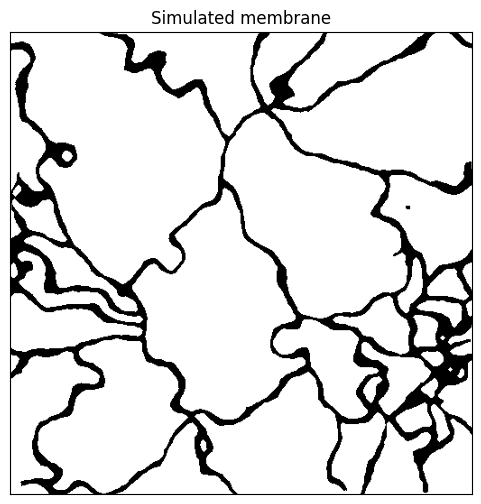

In [13]:
mem_pip.update()
membrane_image = mem_pip.resolve()

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(1 - membrane_image[..., 0], cmap="gray")
ax.set_xlim(pad, image_size_padded - pad)
ax.set_ylim(pad, image_size_padded - pad)
ax.set_title("Simulated membrane")
ax.set_xticks([])
ax.set_yticks([])
plt.show()

### 2.2 Mitochondria

We model each mitochondrion as an ellipse placed at one of the candidate sites reserved during the membrane step, corresponding to the centers of the large Voronoi cells. Several ellipses are drawn per image and the sites are chosen at random, so sometimes more than one mitochondrion ends up on the same site, forming a cluster. Their size and elongation are randomized, and elastic warps deform the ellipses.

In [14]:
def random_ellipse_axes(ellipse_area):
    """Return the three axes of an ellipse."""
    radius_ratio = np.random.beta(1, 3.5) + 1
    major_axis = np.sqrt(ellipse_area) * radius_ratio
    minor_axis = np.sqrt(ellipse_area) / radius_ratio
    z_axis = 0.25
    return (major_axis, minor_axis, z_axis) * dt.units.um


def sample_mitochondrion():
    """Pick a random membrane-defined site; return its (position, axes)."""
    idx = np.random.randint(len(membrane.mitochondria_sites))
    position = membrane.mitochondria_sites[idx]
    area = membrane.mitochondria_size[idx]
    axes = random_ellipse_axes(area**1.75 * 1.6e-7)
    return position, axes


# `position` and `radius` both read from a single `mitochondrion` property.
ellipse = dt.Ellipsoid(
    mitochondrion=sample_mitochondrion,
    position=lambda mitochondrion: mitochondrion[0] + np.random.uniform(-5, 5),
    radius=lambda mitochondrion: mitochondrion[1],
    intensity=1.5,
    rotation=lambda: np.random.uniform(0, 2 * np.pi),
)

In [15]:
mitochondria = (
    (ellipse ^ (lambda: int(np.random.beta(10, 5) * 30)))
    >> dt.ElasticTransformation(
        alpha=70, sigma=8, order=1, ignore_last_dim=True
    )
    >> dt.Pad(px=(10, 10, 10, 10))
    >> dt.ElasticTransformation(
        alpha=lambda: np.random.uniform(20, 120),
        sigma=lambda: np.random.uniform(3, 12),
        order=1,
        ignore_last_dim=False,
    )
    >> dt.CropTight()
)

### 2.3 Noise

The ssTEM images have a busy, textured background. To create a similar-looking background in the simulated images, we build up several kinds of noise that are combined later: noisy background areas, fine speckle, dark spots, ellipses, and stripes.

In [16]:
# The background brightness is uneven in the ssTEM images. To mimic this, we
# scatter many large, low-contrast ellipses into soft brighter/darker patches.
noisy_areas = dt.Ellipse(
    radius=lambda: np.random.uniform(0.5, 5, 2) * 1e-6,
    intensity=lambda: np.random.uniform(-0.1, 0.3),
    position=lambda: np.random.uniform(0, image_size_padded, size=2),
    z=0,
    rotation=lambda: np.random.uniform(0, 2 * np.pi),
)

noisy_areas = ((noisy_areas) ^ 200) >> dt.ElasticTransformation(
    alpha=100, sigma=1, order=1
)
noise_gaussian = noisy_areas >> dt.Gaussian(sigma=0.5)
noisy_areas = noisy_areas * noise_gaussian


# Fine granular texture: many small ellipses scattered densely, with Gaussian
# and Poisson noise.
speckle_ellipse = dt.Ellipse(
    radius=lambda: np.random.uniform(0.3, 0.6, 2) * 1e-6,
    intensity=lambda: np.random.uniform(-0.8, 1),
    position=lambda: np.random.uniform(0, image_size_padded, size=2),
    z=0,
    rotation=lambda: np.random.uniform(0, 2 * np.pi),
)
speckle_noise = ((speckle_ellipse) ^ 1900) >> dt.ElasticTransformation(
    alpha=25, sigma=4.5, order=1
)
speckle_gaussian1 = speckle_noise >> dt.Gaussian(sigma=0.7)
speckle_poisson1 = speckle_noise >> dt.Poisson(snr=0.3, background=1e-4)
speckle_noise = speckle_noise * speckle_gaussian1 * speckle_poisson1


# The images contain occasional dark spots, which we mimic with a handful of
# small, dark ellipsoids.
dark_spot = dt.Ellipsoid(
    radius=lambda: (
        np.random.uniform(0.35, 0.75),
        np.random.uniform(0.35, 0.75),
        np.random.uniform(0.45, 0.75),
    )
    * dt.units.um,
    intensity=lambda: np.random.uniform(1, 5),
    position=lambda: np.random.uniform(0, image_size_padded, size=2),
    z=0,
    rotation=lambda: np.random.uniform(0, 2 * np.pi),
)
dark_spots = (
    (dark_spot) ^ (lambda: np.random.randint(10, 20))
) >> dt.ElasticTransformation(alpha=50, sigma=7, order=1)


# Larger irregular blobs of varying brightness, each given its own Gaussian
# and Poisson noise.
noise_ellipse = dt.Ellipse(
    radius=lambda: np.random.uniform(0.5, 3, 2) * 1e-6,
    intensity=lambda: np.random.uniform(-1, 1.5),
    position=lambda: np.random.uniform(0, image_size_padded, size=2),
    z=0,
    rotation=lambda: np.random.uniform(0, 2 * np.pi),
)

noisy_ellipses = ((noise_ellipse) ^ 100) >> dt.ElasticTransformation(
    alpha=50, sigma=7, order=1
)
ellipse_gaussian = noisy_ellipses >> dt.Gaussian(sigma=5)
ellipse_poisson = noisy_ellipses >> dt.Poisson(snr=0.5, background=1e-4)
noisy_ellipses = noisy_ellipses * ellipse_gaussian * ellipse_poisson


# The images sometimes show elongated, streak-like structures. To resemble
# these, we add a few long, thin ellipses as stripes.
stripe = dt.Ellipse(
    radius=lambda: (
        np.random.uniform(2, 10),  # major axis
        np.random.uniform(0.2, 0.6),  # minor axis
    )
    * dt.units.um,
    intensity=lambda: np.random.uniform(-1, 1),
    position=lambda: np.random.uniform(0, image_size_padded, size=2),
    z=0,
    rotation=lambda: np.random.uniform(0, 2 * np.pi),
)

noisy_stripes = ((stripe) ^ 8) >> dt.ElasticTransformation(
    alpha=50, sigma=7, order=1
)
noise_gaussian_s = noisy_stripes >> dt.Gaussian(sigma=0.3)
noisy_stripes = noisy_stripes * noise_gaussian_s

### 2.4 Optics

The experimental images come from an electron microscope, but we do not model the physics of electron microscopy here. We only try to mimic how the images look. To do that, we combine two of DeepTrack's optical models, `dt.Brightfield` and `dt.Fluorescence`, applying them to different parts of the simulation.

In [17]:
optics = dt.Brightfield(
    wavelength=400e-9,
    NA=lambda: np.random.uniform(0.9, 1.1),
    output_region=(0, 0, image_size_padded, image_size_padded),
)

optics_f = dt.Fluorescence(
    output_region=(0, 0, image_size_padded, image_size_padded),
)

### 2.5 Masks and pipelines

So far we have built the individual structures. Now we combine them into the final simulated image, and we also build the ground-truth masks that mark where the membranes and mitochondria are. For training we need both: the image as the network's input, and the masks as its targets.

We define a small helper function that builds a binary mask from a simulated structure. We use it both to create the ground-truth mitochondria mask and, in the image simulation, to adjust the contrast of the mitochondria: subtracting the mask slightly darkens them so they stand out.

In [18]:
def get_mask():
    """Turn a simulated structure into a binary mask: every non-zero pixel
    becomes foreground."""

    def inner(mask):
        return np.sum(mask, -1, keepdims=True) > 0

    return inner


mito_mask_pip = (
    mitochondria
    >> dt.SampleToMasks(
        get_mask,
        output_region=optics.output_region,
        merge_method="or",
    )
    >> dt.AsType("float")
)

mito_pip = optics(mitochondria) - 0.5 * (
    mitochondria
    >> dt.SampleToMasks(
        get_mask,
        output_region=optics.output_region,
        merge_method="or",
    )
)

Next we assemble the base image. We first create a smooth, large-scale brightness variation, `gray_mask_fn`, that we multiply with the membrane so its intensity varies across the image. We then combine the membrane with the mitochondria and the broad background areas, blur the result slightly, and add a little bit of noise.

In [19]:
base_size = 16
zoom_factor = image_size_padded / base_size
gray_mask_fn = lambda: ndi.zoom(
    np.clip(
        np.random.normal(loc=0.7, scale=0.2, size=(base_size, base_size)),
        0.5,
        1.0,
    ),
    zoom=zoom_factor,
    order=4,
)[..., None]

base_pip = (
    gray_mask_fn * mem_pip * (-1) + 0.6 * mito_pip - 30 * optics_f(noisy_areas)
    >> dt.GaussianBlur(sigma=0.5)
    >> dt.Gaussian(sigma=lambda: np.random.uniform(0.06, 0.09), order=0)
)

We then add the noise textures we defined earlier (speckle, dark spots, stripes, and noisy ellipses) on top of the base image. After that, we clip and blur the result, add Poisson and Gaussian noise, and normalize the image to the range [0, 1].

In [20]:
im_pip = (
    base_pip
    # Granular cytoplasm texture (weighted up to fill the cell interiors).
    + 0.78 * optics(speckle_noise >> dark_spots >> noisy_stripes)
    + 0.4 * optics(noisy_ellipses)
    >> dt.Clip(0.65, 1.9)
    >> dt.AverageBlur(ksize=3)
    >> dt.Poisson(snr=lambda: np.random.uniform(50, 100))
    >> dt.Gaussian(sigma=lambda: np.random.uniform(0.06, 0.09), order=0)
    >> dt.Clip(0.5, 2.1)
    >> dt.NormalizeMinMax()
)

Finally, we bundle the finished image together with its two ground-truth masks (the membrane and the mitochondria), crop away the padding we added earlier, and convert everything to a PyTorch tensor ready for training.

In [21]:
pip = (
    (im_pip & mem_pip & mito_mask_pip)
    >> dt.Crop(crop=(image_size, image_size, 1), corner=(pad, pad))
    >> dt.MoveAxis(2, 0)
    >> dt.pytorch.ToTensor(dtype=torch.float)
)

### 2.6 Visualize a simulated sample

Let's generate one simulated sample and look at it. The first panel shows the simulated image, and the next three show its ground-truth channels: the membrane, the intracellular region, and the mitochondria.

c:\Users/xgrmir/Documents/DeepTrack2/DeepTrack2\deeptrack\optical\optics.py:1878: UserWarning: Brightfield imaging from ScatteredVolume assumes a weak-phase / projection approximation. Use ScatteredField for physically accurate brightfield simulations.
  warnings.warn(
c:\Users/xgrmir/Documents/DeepTrack2/DeepTrack2\deeptrack\optical\optics.py:1899: UserWarning: Scatterer defines 'intensity', which is ignored in brightfield microscopy.
  warnings.warn(
c:\Users/xgrmir/Documents/DeepTrack2/DeepTrack2\deeptrack\optical\optics.py:1908: UserWarning: No 'refractive_index' specified; using 'value' as a non-physical brightfield contrast. Results are not physically calibrated. Define 'refractive_index' for physically meaningful contrast.
  warnings.warn(
C:\Users\xgrmir\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\scipy\ndimage\_measurements.py:1548: RuntimeWarning: invalid value encountered in scalar divide
  resul

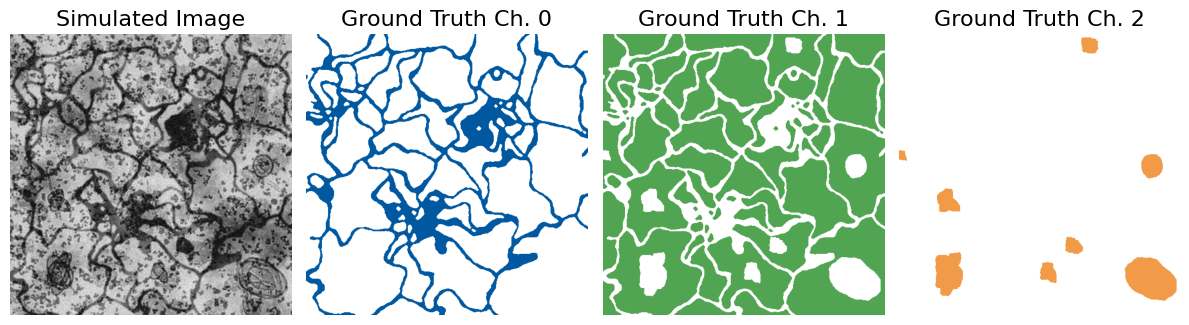

In [22]:
pip.update()

sim_im, mem_mask, mito_mask = pip.resolve()
sim_im = torch.as_tensor(sim_im)
mem_mask = torch.as_tensor(mem_mask)
mito_mask = torch.as_tensor(mito_mask)

intra_cellular_mask = torch.ones((image_size, image_size)) - torch.max(
    mem_mask, mito_mask
)
masks = [mem_mask, intra_cellular_mask, mito_mask]
masks = torch.concat(masks, axis=0)

plot_channels(sim_im, masks, image_title="Simulated Image")

Let's place a simulated image next to an experimental one to see how similar they look.

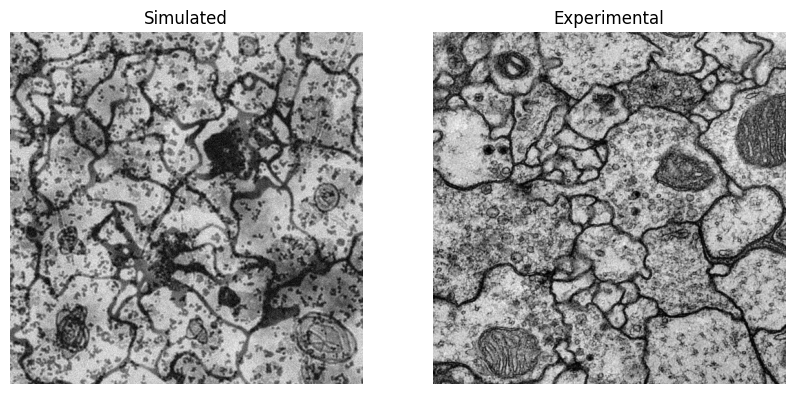

In [23]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].imshow(sim_im[0], cmap="gray")
ax[0].set_title("Simulated")
ax[0].set_axis_off()

ax[1].imshow(exp_image_crop[0], cmap="gray")
ax[1].set_title("Experimental")
ax[1].set_axis_off()

plt.show()

As a more quantitative check, we compare the pixel-intensity distributions of the simulated and experimental images. If the simulation resembles the real data, the histograms should roughly overlap. Here we plot the histograms of the experimental and simulated images.

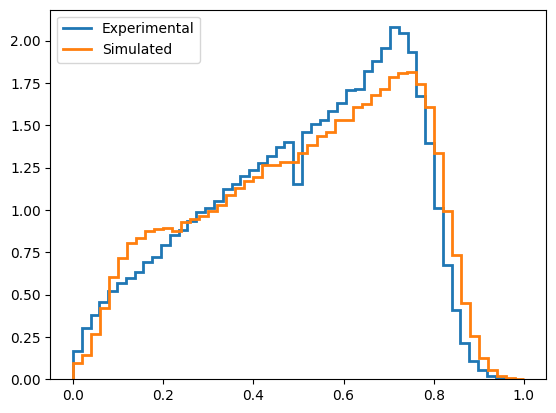

In [24]:
num_bins = 50

hist_exp, bins_exp = np.histogram(exp_image_crop.flatten(), bins=num_bins, density=True)
plt.stairs(hist_exp, bins_exp, label="Experimental", lw=2)

hist, bins = np.histogram(sim_im.flatten(), bins=num_bins, density=True)
plt.stairs(hist, bins, label="Simulated", lw=2)

plt.legend()
plt.show();

## 3. Create a dataset

Now that the pipeline can produce a simulated image together with its ground-truth masks, we generate a full dataset to train the neural network on later. We create a set of training samples and a smaller set of validation samples, where each sample is a 4-channel tensor: the simulated image plus the three ground-truth channels (membrane, intracellular region, and mitochondria).

In [25]:
def generate_dataset(num_samples):
    """Simulate `num_samples` samples, each a 4-channel tensor (image and
    membrane, intracellular, and mitochondria masks)."""

    output = torch.zeros((num_samples, 4, image_size, image_size))

    for j in range(num_samples):
        if j % 10 == 0:
            print("sample:", j)

        pip.update()
        im, mem_mask, mito_mask = pip.resolve()
        im = torch.as_tensor(im)
        mem_mask = torch.as_tensor(mem_mask)
        mito_mask = torch.as_tensor(mito_mask)

        intra_cellular_mask = torch.ones((image_size, image_size)) - torch.max(
            mem_mask, mito_mask
        )
        masks = [mem_mask, intra_cellular_mask, mito_mask]
        masks = torch.concat(masks, axis=0)

        output[j] = torch.concat([im, masks], axis=0)

    return output

In [26]:
num_train_samples = 100
num_val_samples = 20

train_data = generate_dataset(num_train_samples)
val_data = generate_dataset(num_val_samples)

sample: 0
sample: 10
sample: 20
sample: 30
sample: 40
sample: 50
sample: 60
sample: 70
sample: 80
sample: 90
sample: 0
sample: 10


## 4. Prepare the data for training

Before training, we wrap the simulated tensors in a PyTorch `Dataset`. It splits each sample into the image and its three mask channels, and applies random augmentations (rotations and flips) so the network sees more variation.

In [27]:
class SimulatedDataset(Dataset):
    """Wrap the simulated tensor as a PyTorch dataset: split each sample into
    its image and mask channels, and optionally augment it."""

    def __init__(self, data_tensor, augment=True):
        super().__init__()
        self.data = data_tensor
        self.augment = augment
        
        # Random flips and 90-degree rotations, applied to the whole sample
        # so the image and masks stay aligned.
        self.augmentation = (
            dt.FlipLR()
            >> dt.FlipUD()
            >> dt.FlipDiagonal()
            >> dt.MoveAxis(2, 0)
            >> dt.pytorch.ToTensor(dtype=torch.float)
        )

    def __len__(self):
        return self.data.shape[0]

    def __getitem__(self, idx):
        sample = self.data[idx]  # (4, H, W): image + 3 mask channels

        if self.augment:
            sample = sample.permute(1, 2, 0).numpy()
            sample = self.augmentation.update()(sample)

        image = sample[0:1]  # (1, H, W)
        masks = sample[1:]   # (3, H, W)
        return image, masks

In [28]:
train_dataset = SimulatedDataset(train_data, augment=True)
val_dataset = SimulatedDataset(val_data, augment=False)

Let's look at one augmented training sample with its ground-truth channels.

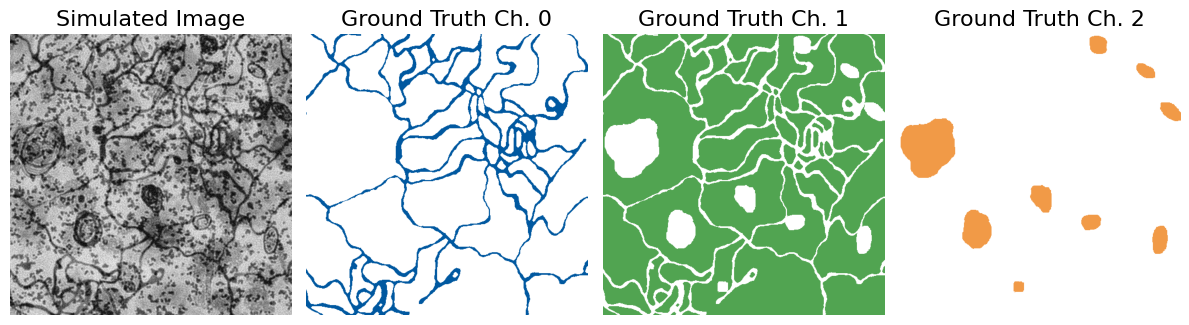

In [29]:
sim_im, segmentation = train_dataset[-1]

plot_channels(sim_im, segmentation, image_title="Simulated Image")

## 5. Define and train the U-Net

We now define the U-Net and its metric, and train it on the simulated data.

We measure segmentation quality with the Jaccard Index (intersection over union). `ArgmaxJI` takes the argmax over the class channels first, so it compares the predicted and true class label at each pixel.

In [30]:
class ArgmaxJI(MulticlassJaccardIndex):
    """Compute Jaccard Index for multi-class predictions after argmax."""

    def update(self, preds, targets):
        super().update(preds.argmax(dim=1), targets.argmax(dim=1))


ji_metric = ArgmaxJI(num_classes=3)
ji_metric_per_class = ArgmaxJI(num_classes=3, average=None)

We use a U-Net that takes the single-channel image and outputs three channels, one per class. It is wrapped in a `Regressor` with a cross-entropy loss and the Jaccard metric.

In [31]:
unet = dl.UNet2d(
    in_channels=1,
    channels=[16, 32, 64, 128, 256],
    out_channels=3,
    skip=dl.Cat(),
)

unet_reg_template = dl.Regressor(
    model=unet,
    loss=torch.nn.CrossEntropyLoss(),
    metrics=[ji_metric],
    optimizer=dl.Adam(),
)

print(unet_reg_template)

Regressor(
  (loss): CrossEntropyLoss()
  (optimizer): Adam[Adam]()
  (train_metrics): MetricCollection(
    (ArgmaxJI): ArgmaxJI(),
    prefix=train
  )
  (val_metrics): MetricCollection(
    (ArgmaxJI): ArgmaxJI(),
    prefix=val
  )
  (test_metrics): MetricCollection(
    (ArgmaxJI): ArgmaxJI(),
    prefix=test
  )
  (model): UNet2d(
    (encoder): ConvolutionalEncoder2d(
      (blocks): LayerList(
        (0): Conv2dBlock(
          (layer): Layer[Conv2d](in_channels=1, out_channels=16, kernel_size=3, stride=1, padding=1)
          (activation): Layer[ReLU]()
        )
        (1): Conv2dBlock(
          (pool): Layer[MaxPool2d](kernel_size=2, stride=2)
          (layer): Layer[Conv2d](in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1)
          (activation): Layer[ReLU]()
        )
        (2): Conv2dBlock(
          (pool): Layer[MaxPool2d](kernel_size=2, stride=2)
          (layer): Layer[Conv2d](in_channels=32, out_channels=64, kernel_size=3, stride=1, padding

We wrap the datasets in data loaders, which feed the images to the model in batches during training.

In [32]:
train_loader = dl.DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader = dl.DataLoader(val_dataset, batch_size=4)

We train with early stopping: training continues until the validation Jaccard Index stops improving (patience of 30 epochs), up to 300 epochs, and the best checkpoint is saved along the way.

In [33]:
unet_reg = unet_reg_template.create()

early_stopping = EarlyStopping(
    monitor="valArgmaxJI_epoch", mode="max", patience=30
)
logger = CSVLogger("logs", name="train_until_stagnation")
checkpoint = callbacks.ModelCheckpoint(
    monitor="valArgmaxJI_epoch", mode="max", save_top_k=1
)

trainer = dl.Trainer(
    max_epochs=300,
    logger=logger,
    callbacks=[early_stopping, checkpoint],
    accelerator="auto",
)
trainer.fit(unet_reg, train_loader, val_loader)


  | Name          | Type             | Params
---------------------------------------------------
0 | loss          | CrossEntropyLoss | 0     
1 | train_metrics | MetricCollection | 0     
2 | val_metrics   | MetricCollection | 0     
3 | test_metrics  | MetricCollection | 0     
4 | model         | UNet2d           | 2.1 M 
5 | optimizer     | Adam             | 0     
---------------------------------------------------
2.1 M     Trainable params
0         Non-trainable params
2.1 M     Total params
8.466     Total estimated model params size (MB)


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

C:\Users\xgrmir\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:441: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.
C:\Users\xgrmir\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:441: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.
C:\Users\xgrmir\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\lightning\pytorch\loops\fit_loop.py:298: The number of tra

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

After training, we plot how the loss and the Jaccard Index evolved over the epochs, for both the training and validation sets.

In [34]:
def plot_training_metrics(m):
    """Plot training metrics by epoch."""
    fig, axs = plt.subplots(2, figsize=(6, 4))

    axs[0].plot(m["epoch"], m["train_loss_epoch"], label="Train Loss")
    axs[0].plot(m["epoch"], m["val_loss_epoch"], label="Validation Loss")
    axs[0].set_xlabel("Epoch")
    axs[0].set_ylabel("Loss")
    axs[0].legend()

    axs[1].plot(m["epoch"], m["trainArgmaxJI_epoch"], label="Train JI")
    axs[1].plot(m["epoch"], m["valArgmaxJI_epoch"], label="Validation JI")
    axs[1].set_xlabel("Epoch")
    axs[1].set_ylabel("Jaccard Index (JI)")
    axs[1].legend()

    plt.tight_layout()
    plt.show()

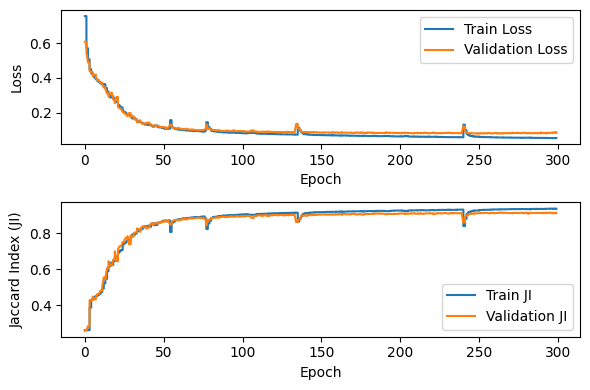

In [35]:
metrics = pd.read_csv(
    os.path.join(logger.log_dir, "metrics.csv")
).ffill()

plot_training_metrics(metrics)

## 6. Evaluate on experimental data

The real test is how well the model, trained only on simulated data, segments the actual ssTEM images. We load the best checkpoint and run it on the experimental dataset.

In [36]:
best_ckpt_path = checkpoint.best_model_path
best_unet_reg = dl.Regressor.load_from_checkpoint(best_ckpt_path)

We run the model on all experimental images to get the predicted segmentations, keeping them in dataset order (`shuffle=False`) so each prediction can be matched with its ground truth.

In [37]:
exp_loader = dl.DataLoader(exp_dataset, batch_size=10, shuffle=False)

pred_seg_exp = torch.cat(trainer.predict(best_unet_reg, exp_loader), dim=0)

C:\Users\xgrmir\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:441: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.


Predicting: |          | 0/? [00:00<?, ?it/s]

We measure how well the predictions match the ground truth using the Jaccard Index and the Dice score. Looping over the experimental images, we compute the score for each and report both the overall average and the average per class (membrane, intracellular region, and mitochondria). The two measures are computed from the same true positives, false positives, and false negatives, so the Dice score follows directly from the Jaccard index.

In [38]:
ji_metric.reset()
ji_metric_per_class.reset()

ji = np.zeros(len(exp_dataset))
ji_per_class = torch.zeros((len(exp_dataset), 3))

for sample in range(len(exp_dataset)):
    exp_image, exp_seg = exp_dataset[sample]
    ji_sample = ji_metric(
        pred_seg_exp[sample].unsqueeze(0), exp_seg.unsqueeze(0)
    )
    ji[sample] = ji_sample

    ji_sample_per_class = ji_metric_per_class(
        pred_seg_exp[sample].unsqueeze(0), exp_seg.unsqueeze(0)
    )
    ji_per_class[sample, :] = ji_sample_per_class

# The Dice score follows from the Jaccard index, since both are computed
# from the same true positives, false positives and false negatives.
dice_per_class = 2 * ji_per_class / (1 + ji_per_class)
dice = dice_per_class.mean(dim=1).numpy()


print(
    f"average jaccard index: {np.mean(ji):.3f}, \n"
    f"average jaccard index per class: \n"
    f"  membrane: {torch.mean(ji_per_class, dim=0)[0]:.3f}\n"
    f"  intracellular: {torch.mean(ji_per_class, dim=0)[1]:.3f}\n"
    f"  mitochondria: {torch.mean(ji_per_class, dim=0)[2]:.3f}\n\n"
    f"average dice score: {np.mean(dice):.3f}, \n"
    f"average dice score per class: \n"
    f"  membrane: {torch.mean(dice_per_class, dim=0)[0]:.3f}\n"
    f"  intracellular: {torch.mean(dice_per_class, dim=0)[1]:.3f}\n"
    f"  mitochondria: {torch.mean(dice_per_class, dim=0)[2]:.3f}"
)

average jaccard index: 0.726, 
average jaccard index per class: 
  membrane: 0.672
  intracellular: 0.891
  mitochondria: 0.614

average dice score: 0.835, 
average dice score per class: 
  membrane: 0.804
  intracellular: 0.942
  mitochondria: 0.758


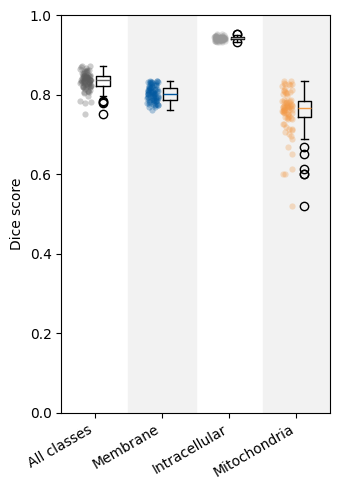

In [ ]:
metrics = {
    "All classes": (dice, "#5c5c5cff"),
    "Membrane": (dice_per_class[:, 0], channel_colors[0]),
    "Intracellular": (dice_per_class[:, 1], '#999999ff'),
    "Mitochondria": (dice_per_class[:, 2], channel_colors[2]),
}

fig, ax = plt.subplots(figsize=(3.5, 5))
shift = 0.12

for m, (values, color) in enumerate(metrics.values()):
    ax.boxplot(
        values,
        positions=[m + shift],
        widths=0.2,
        medianprops=dict(color=color),
    )

    x = m + shift - 0.26 + np.random.uniform(-0.08, 0.08, len(values))
    ax.scatter(x, values, s=20, alpha=0.3, color=color, linewidths=0)

for m in range(1, len(metrics), 2):
    ax.axvspan(m - 0.5, m + 0.5, color="0.95", zorder=0)

ax.set_xticks(range(len(metrics)), list(metrics), rotation=30, ha="right")
ax.set_xlim(-0.5, len(metrics) - 0.5)
ax.set_ylim(0, 1.0)
ax.set_ylabel("Dice score")

fig.tight_layout()

To inspect the segmentation qualitatively, we show the image next to the ground-truth segmentation and the model's prediction for one experimental sample.

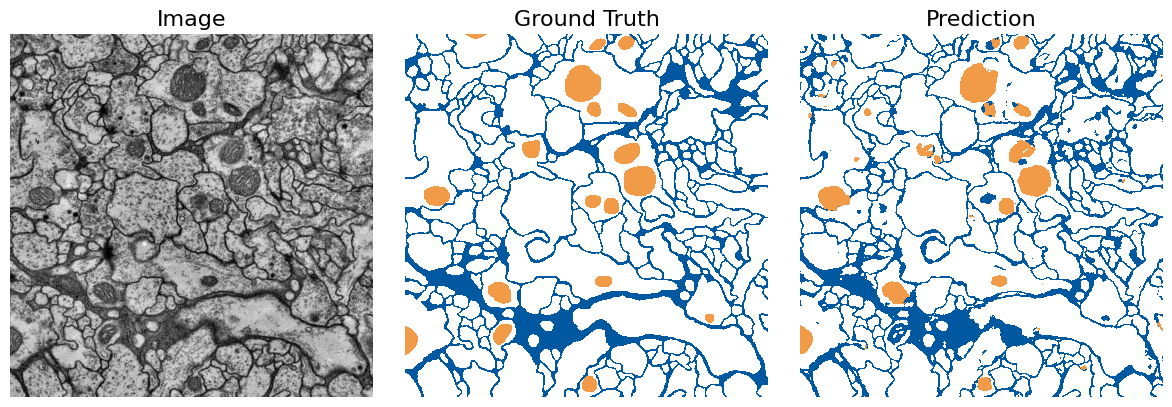

In [39]:
best_sample = int(np.argmax(ji))
exp_image, exp_seg = exp_dataset[best_sample]

fig, axs = plt.subplots(1, 3, figsize=(12, 4))

axs[0].imshow(exp_image[0], cmap="gray")
axs[0].set_title("Image", fontsize=16)
axs[0].axis("off")

axs[1].imshow(exp_seg.argmax(dim=0), cmap=seg_cmap, interpolation="nearest")
axs[1].set_title("Ground Truth", fontsize=16)
axs[1].axis("off")

axs[2].imshow(
    pred_seg_exp[best_sample].argmax(dim=0),
    cmap=seg_cmap,
    interpolation="nearest",
)
axs[2].set_title("Prediction", fontsize=16)
axs[2].axis("off")

plt.tight_layout()
plt.show()